###  MicroGrad demo

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

(100, 2)
[-1  1 -1  1  1 -1 -1 -1  1  1  1 -1 -1 -1 -1  1 -1  1 -1 -1  1 -1 -1  1
  1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1  1 -1  1  1  1 -1 -1
  1  1  1 -1  1  1 -1 -1 -1 -1  1  1 -1 -1  1  1 -1 -1  1  1  1  1  1  1
  1  1 -1  1 -1  1  1 -1  1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1  1 -1 -1
 -1  1 -1 -1]


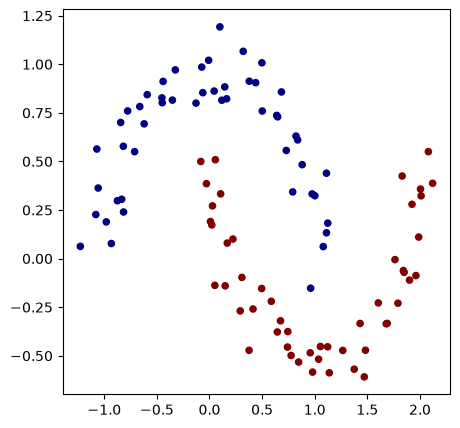

In [8]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)
print(X.shape)

y = y*2 - 1 # make y be -1 or 1
print(y)
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [9]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [ ]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        print(f'ri:{ri}')
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    print(f'inputs:{inputs}')
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    print(f'scores:{scores}')
    print(f'yb:{yb}')
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    print(f'loses:{losses}')
    data_loss = sum(losses) * (1.0 / len(losses))
    print(f'data_losss:{data_loss}')
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    print(f'total_loss:{total_loss}')
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    print(f'accuracy:{accuracy}')
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss(1)
print(total_loss, acc)

ri:[15]
inputs:[[Value(data=1.6890388109912613, grad=0), Value(data=-0.333317141685175, grad=0)]]
scores:[Value(data=3.373158515787453, grad=0)]
xb:[1]
loses:[Value(data=0, grad=0)]
data_losss:Value(data=0.0, grad=0)
total_loss:Value(data=0.011010056494020261, grad=0)
accuracy:[np.True_]
Value(data=0.011010056494020261, grad=0) 1.0


In [11]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")


inputs:[[Value(data=-0.008221677036228253, grad=0), Value(data=1.020456681805996, grad=0)], [Value(data=0.9574772340029193, grad=0), Value(data=-0.4847192336734186, grad=0)], [Value(data=0.6387595106126684, grad=0), Value(data=0.7368995818210089, grad=0)], [Value(data=2.12019255549089, grad=0), Value(data=0.3876264967841906, grad=0)], [Value(data=1.4709969784514492, grad=0), Value(data=-0.6086487731450797, grad=0)], [Value(data=-0.44075488008445785, grad=0), Value(data=0.9117585158359088, grad=0)], [Value(data=-0.8437571602462076, grad=0), Value(data=0.700564185031499, grad=0)], [Value(data=-0.32493231580354015, grad=0), Value(data=0.970952152168812, grad=0)], [Value(data=0.3759829172118385, grad=0), Value(data=-0.4718020736228759, grad=0)], [Value(data=0.30802103044398277, grad=0), Value(data=-0.09675000867739023, grad=0)], [Value(data=0.7754594140319774, grad=0), Value(data=-0.4985258681609307, grad=0)], [Value(data=0.3203549860946353, grad=0), Value(data=1.0666285255925179, grad=0)]

(-1.6086487731450796, 2.1413512268549204)

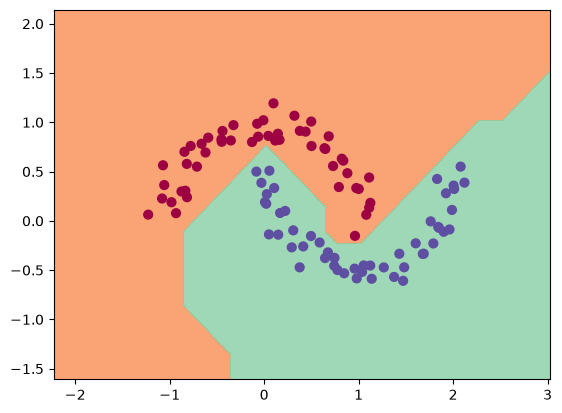

In [14]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
